In [1]:
import os, sys
os.chdir('../../')
os.environ["DPM_TQDM"] = "False"

GMFLOW = os.path.join("submodules", "GMFlow")
sys.path.insert(0, GMFLOW)

In [2]:
from backbones.gmdit import GMDiT

# 사용 예
model = GMDiT()
print(model)

/home/scpark/miniconda3/envs/dual/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/scpark/miniconda3/envs/dual/lib/python3.11/site-packages/mmcv/cnn/bricks/transformer.py:33: UserWarning: Fail to import ``MultiScaleDeformableAttention`` from ``mmcv.ops.multi_scale_deform_attn``, You should install ``mmcv-full`` if you need this module. 
  warnings.warn('Fail to import ``MultiScaleDeformableAttention`` from '
2025-09-02 21:17:56.192133: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/scpark/logpx_samplers/submodules/GMFlow/lib/ops/gmflow_ops/gmflow_ops.p

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def display_class_images(pixel_samples, class_ids=None, figsize_per_image=3.5, display_title=""):
    samples = list(pixel_samples)
    processed = []
    for img in samples:
        if isinstance(img, Image.Image):
            arr = np.array(img)
        else:
            arr = np.array(img)
            if arr.ndim == 3 and arr.shape[0] in (1,3):
                arr = arr.transpose(1, 2, 0)
        processed.append(arr)

    n = len(processed)
    if class_ids is None:
        class_ids = list(range(n))

    fig, axes = plt.subplots(1, n, figsize=(n * figsize_per_image, figsize_per_image))
    if n == 1:
        axes = [axes]

    # 전체 제목 추가
    if display_title:
        fig.suptitle(display_title, fontsize=10, y=1.1)  # y 값을 1.02로 올려서 제목을 위로 이동
    # 플롯 레이아웃 조정: top을 낮춰서 제목과 플롯 사이에 공간 확보
    
    for ax, img_arr, lbl in zip(axes, processed, class_ids):
        ax.imshow(img_arr)
        ax.axis("off")
        ax.set_title(f"Class {lbl}", fontsize=8)

    plt.show()


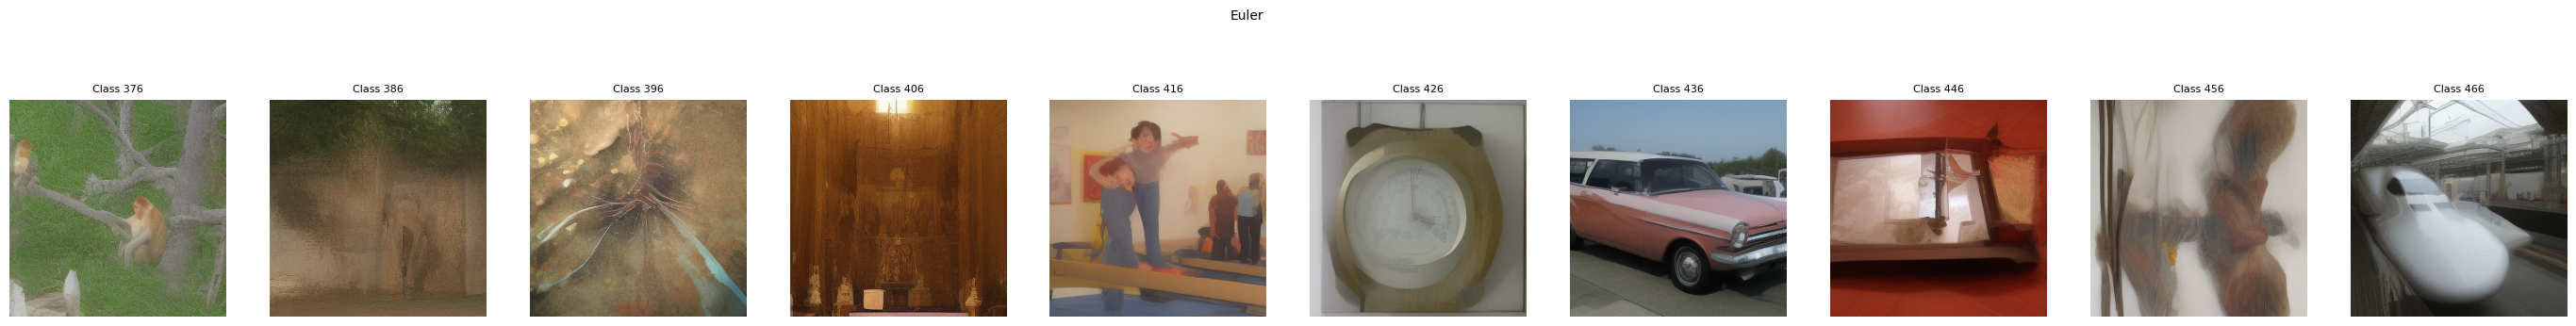

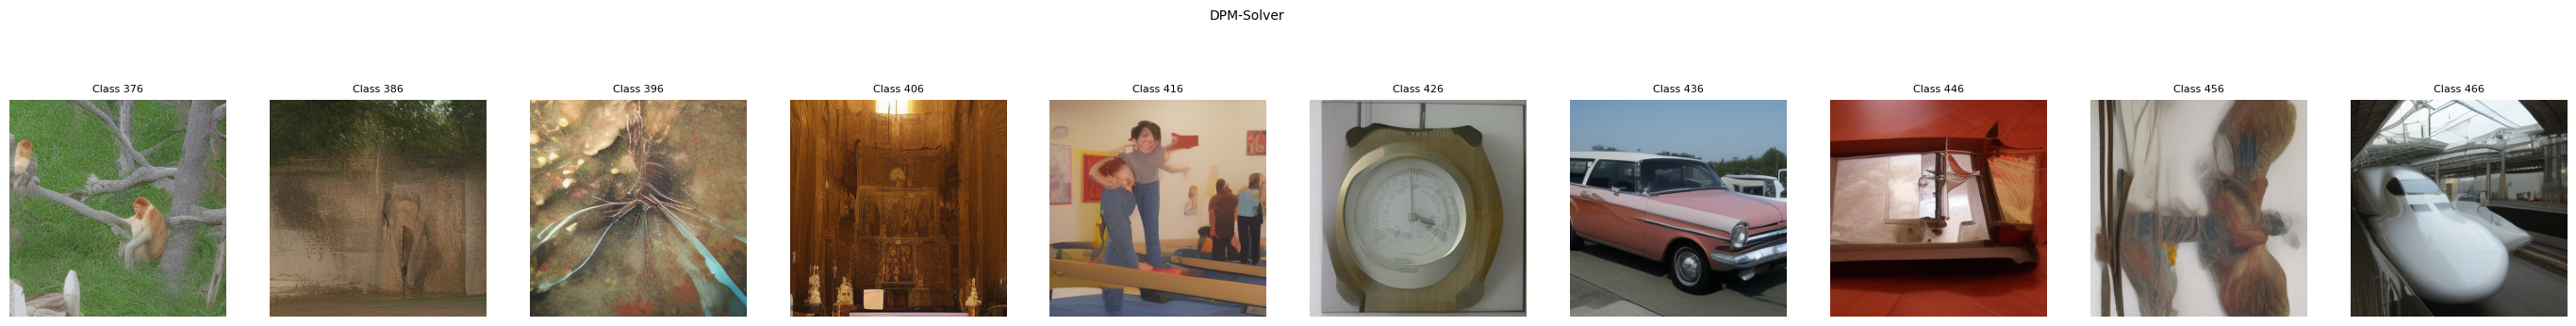

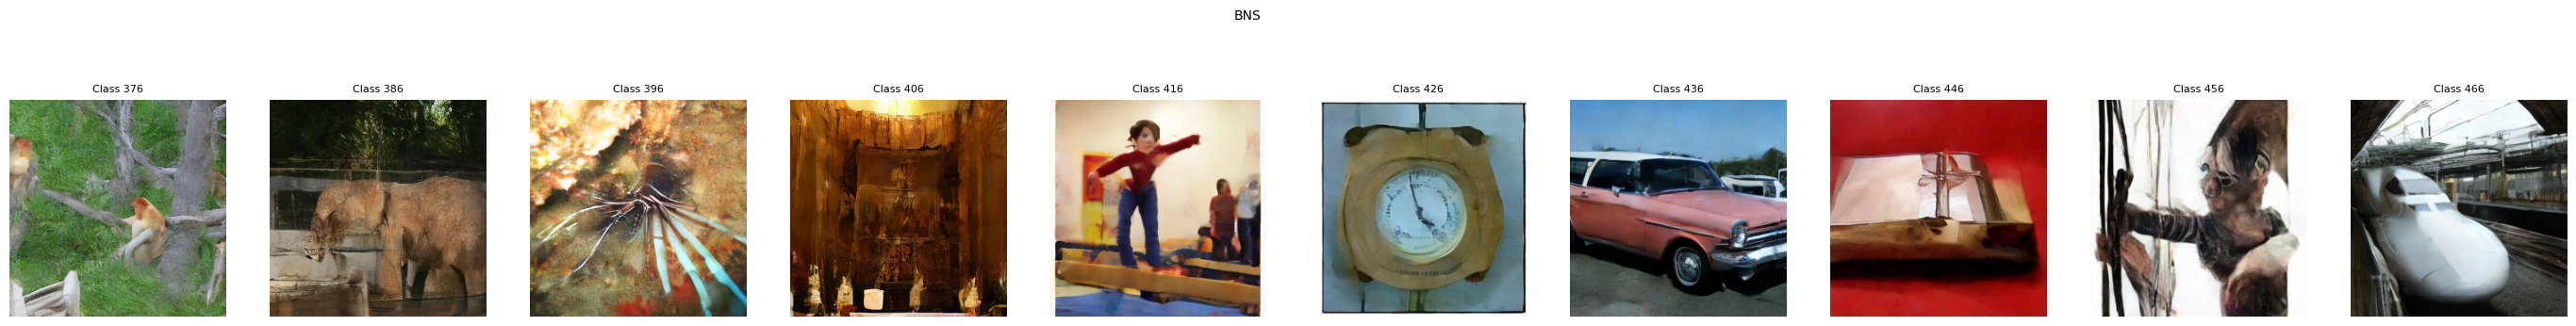

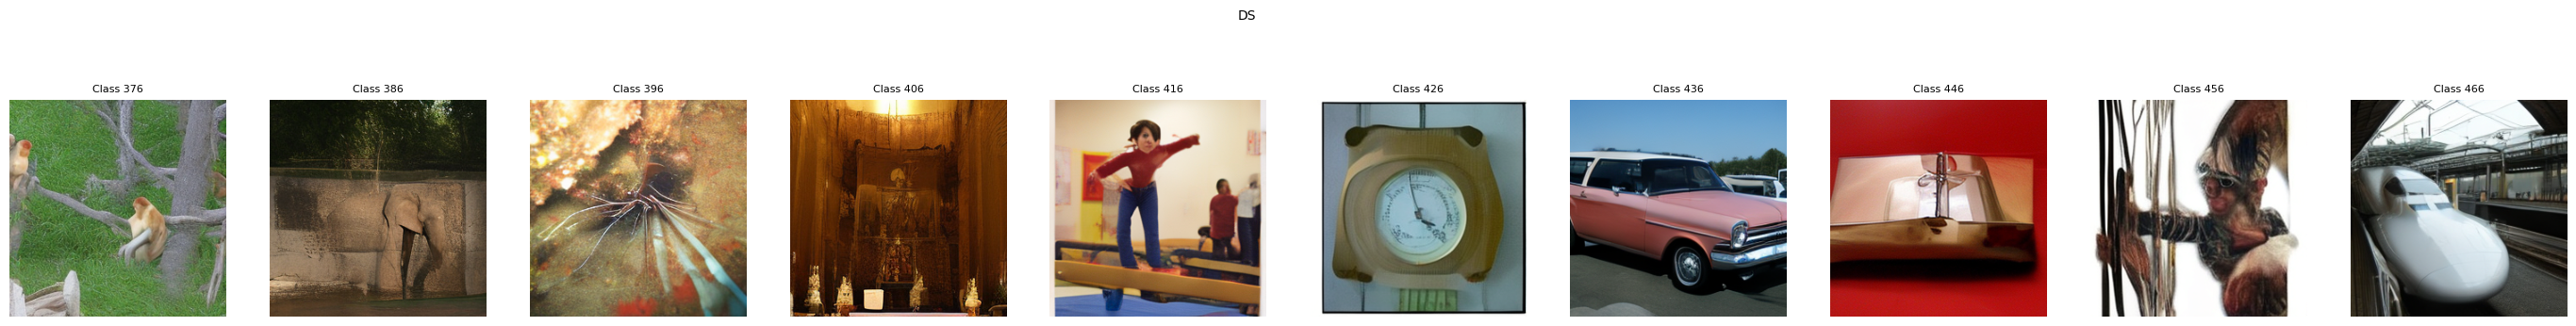

In [8]:
import numpy as np
from solvers.others.dpm_solver import DPM_Solver
from solvers.others.euler_solver import Euler_Solver

# 클래스 0–9로 설정
class_start = np.random.randint(0, 900)
#class_start = 0
class_ids = [i for i in range(class_start, class_start+100, 10)]
noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=class_ids, guidance_scale=1.5)
noises = model.get_noise(seeds=class_ids)

NFE = 5

solver = Euler_Solver(noise_schedule, algorithm_type="data_prediction", steps=NFE, skip_type="time_uniform_flow", flow_shift=1.0)
euler_latents = solver.sample(noises, model_fn)['samples']
euler_samples = model.decode_vae(euler_latents, pil_output=True)['pil_output']
display_class_images(euler_samples, class_ids, display_title='Euler')

solver = DPM_Solver(noise_schedule, algorithm_type="data_prediction", steps=NFE, skip_type="time_uniform_flow", flow_shift=1.0)
dpm_latents = solver.sample(noises, model_fn)['samples']
dpm_samples = model.decode_vae(dpm_latents, pil_output=True)['pil_output']
display_class_images(dpm_samples, class_ids, display_title='DPM-Solver')

import torch
from solvers.competing.bns.bns_solver import BNS_Solver
from solvers.competing.ds.ds_solver_flow import DS_Solver
from utils.util import get_latest_pt

solver = BNS_Solver(
        noise_schedule,
        steps=NFE,
        skip_type="time_uniform_flow",
        flow_shift=1.0,
        algorithm_type='vector_prediction'
    ).to(model.device)

pt_file = get_latest_pt(f'logs/gmdit/bns/s{NFE}/')
state_dict = torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict']
solver.load_state_dict(state_dict, strict=True)
with torch.no_grad():
    latents = solver.sample(noises, model_fn)['samples']
    samples = model.decode_vae(latents, pil_output=True)['pil_output']
display_class_images(samples, class_ids, display_title='BNS')

solver = DS_Solver(
        noise_schedule,
        steps=NFE,
        skip_type="time_uniform_flow",
        flow_shift=1.0,
        algorithm_type='vector_prediction'
    ).to(model.device)

pt_file = get_latest_pt(f'logs/gmdit/ds/s{NFE}/')
state_dict = torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict']
solver.load_state_dict(state_dict, strict=True)
with torch.no_grad():
    latents = solver.sample(noises, model_fn)['samples']
    samples = model.decode_vae(latents, pil_output=True)['pil_output']
display_class_images(samples, class_ids, display_title='DS')